In [1]:
###################################### src/as_model.py
import numpy as np

def calculate_spread(mid_price: float, inventory: float,
                    volatility: float, gamma: float = 0.1) -> tuple[float, float]:
    """Your original A-S implementation"""
    spread = gamma * (volatility ** 2) * (1 - (inventory ** 2))
    return (mid_price - spread / 2, mid_price + spread / 2)

In [2]:

def calculate_spread(mid_price, inventory, volatility, gamma=666.67):  # Gamma tuned for δ=20
    spread = gamma * (volatility ** 2) * (1 - (inventory ** 2))
    return (mid_price - spread / 2, mid_price + spread / 2)

bid, ask = calculate_spread(2000, 0.5, 0.2)  # Now gamma=666.67
print(f"Bid: {bid:.2f}, Ask: {ask:.2f}")      # Output: Bid: 1990.00, Ask: 2010.00

Bid: 1990.00, Ask: 2010.00


In [29]:
# Design the RL Environment
# src/env.py
import gym
import numpy as np

class TradingEnv(gym.Env):
    def __init__(self, data):
        self.data = data  # Your aligned CEX/on-chain data
        self.action_space = gym.spaces.Box(low=-1, high=1, shape=(2,))  # [bid_adj, ask_adj]
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(8,))  # 8 features

    def step(self, action):
        # 1. Get current state (price, vol, inventory, etc.)
        state = self._get_state()

        # 2. Apply action (adjust A-S spreads)
        new_bid = state['bid'] * (1 + action[0])
        new_ask = state['ask'] * (1 + action[1])

        # 3. Calculate reward (your MBA risk management)
        reward = self._calculate_pnl(new_bid, new_ask) - 0.5 * abs(state['inventory'])

        # 4. Update environment
        self.current_step += 1
        done = self.current_step >= len(self.data)

        return state, reward, done, {}

    def _get_state(self):
        """Your feature engineering skills here"""
        return {
            'price': self.data[self.current_step]['price'],
            'volatility': self.data[self.current_step]['vol'],
            'inventory': self.data[self.current_step]['inv'],
            # ... +5 more features
        }

In [4]:
!pip install python-binance web3 pandas numpy stable-baselines3 gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.5/587.5 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211

In [5]:
import pandas as pd
from binance.client import Client  # Now works!
import web3

/usr/local/lib/python3.11/dist-packages/binance/ws/websocket_api.py:4: DeprecationWarning: websockets.WebSocketClientProtocol is deprecated
  from websockets import WebSocketClientProtocol  # type: ignore
/usr/local/lib/python3.11/dist-packages/websockets/legacy/__init__.py:6: DeprecationWarning: websockets.legacy is deprecated; see https://websockets.readthedocs.io/en/stable/howto/upgrade.html for upgrade instructions
  warnings.warn(  # deprecated in 14.0 - 2024-11-09


In [7]:
from binance import ThreadedWebsocketManager

testnet_client = Client(
    api_key="testnet-api-key",
    api_secret="testnet-api-secret",
    testnet=True  # Enables testnet mode
)

In [8]:
def fetch_binance_data(self, pair="ETHUSDT", lookback="100d"):
    klines = self.binance.get_historical_klines(
        pair, Client.KLINE_INTERVAL_1HOUR, lookback
    )
    # Binance returns 12 columns:
    # [timestamp, open, high, low, close, volume, close_time, quote_volume, trades,
    #  taker_buy_volume, taker_quote_volume, ignore]
    columns = [
        "timestamp", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "trades",
        "taker_buy_volume", "taker_quote_volume", "ignore"
    ]
    df = pd.DataFrame(klines, columns=columns)

    # Convert and filter key columns (your stats skills apply)
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    return df[["timestamp", "open", "high", "low", "close", "volume"]].set_index("timestamp")

In [9]:
def fetch_binance_data(self, pair="ETHUSDT", lookback="100d"):
    # Get DataFrame directly with OHLCV columns
    df = self.binance.get_historical_klines_as_df(
        pair, Client.KLINE_INTERVAL_1HOUR, lookback
    )
    df = df[["open_time", "open", "high", "low", "close", "volume"]]
    df.rename(columns={"open_time": "timestamp"}, inplace=True)
    return df.set_index("timestamp")

In [10]:
# data_loader.py (Binance + On-Chain Data)
import pandas as pd
from binance.client import Client

class DataLoader:
    def __init__(self, api_key, api_secret):
        self.binance = Client(api_key, api_secret)

    def fetch_binance_data(self, pair="ETHUSDT", lookback="100d"):
        """Fully handles Binance's 12-column format"""
        klines = self.binance.get_historical_klines(
            pair, Client.KLINE_INTERVAL_1HOUR, lookback
        )

        # Binance's 12 default columns (see https://python-binance.readthedocs.io)
        columns = [
            "timestamp", "open", "high", "low", "close", "volume",
            "close_time", "quote_volume", "trades",
            "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
        ]

        # Convert to DataFrame
        df = pd.DataFrame(klines, columns=columns)

        # Convert timestamp and filter columns (your stats skills apply)
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        return df[["timestamp", "open", "high", "low", "close", "volume"]].set_index("timestamp")

# Usage (Test in Colab)
loader = DataLoader(api_key="YOUR_KEY", api_secret="YOUR_SECRET")
try:
    data = loader.fetch_binance_data()
    print(data.head())  # Should show OHLCV data
except Exception as e:
    print(f"Error: {e}")
    print("Tip: Use mock data if APIs fail (see below)")


                              open           high            low  \
timestamp                                                          
2025-01-21 22:00:00  3331.90000000  3347.12000000  3326.70000000   
2025-01-21 23:00:00  3333.75000000  3334.89000000  3308.11000000   
2025-01-22 00:00:00  3327.55000000  3365.99000000  3323.37000000   
2025-01-22 01:00:00  3361.54000000  3361.55000000  3321.31000000   
2025-01-22 02:00:00  3328.84000000  3347.00000000  3322.00000000   

                             close          volume  
timestamp                                           
2025-01-21 22:00:00  3333.74000000   8771.23470000  
2025-01-21 23:00:00  3327.54000000  15981.15480000  
2025-01-22 00:00:00  3361.54000000  17379.48940000  
2025-01-22 01:00:00  3328.84000000  16728.47700000  
2025-01-22 02:00:00  3343.77000000  15037.27160000  


In [11]:
import pandas as pd
import numpy as np
from binance.client import Client
from web3 import Web3

class DataLoader:
    def __init__(self, binance_api_key=None, binance_secret=None, infura_url=None):
        self.binance = Client(binance_api_key, binance_secret) if binance_api_key else None
        self.web3 = Web3(Web3.HTTPProvider(infura_url)) if infura_url else None

    def fetch_binance_data(self, pair="ETHUSDT", lookback="100d"):
        """Fetches Binance data with mock fallback"""
        try:
            klines = self.binance.get_historical_klines(pair, Client.KLINE_INTERVAL_1HOUR, lookback)
            df = pd.DataFrame(klines, columns=[
                "timestamp", "open", "high", "low", "close", "volume",
                "close_time", "quote_volume", "trades", "taker_buy_base", "taker_buy_quote", "ignore"
            ])
            df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
            return df[["timestamp", "open", "high", "low", "close", "volume"]].set_index("timestamp")
        except:
            return self._mock_binance_data()

    def _mock_binance_data(self):
        """Generates realistic mock OHLCV data"""
        dates = pd.date_range("2023-01-01", periods=100, freq="h")
        base_prices = 2000 + np.cumsum(np.random.normal(0, 5, len(dates)))
        return pd.DataFrame({
            "timestamp": dates,
            "open": base_prices,
            "high": base_prices + np.random.uniform(1, 3, len(dates)),
            "low": base_prices - np.random.uniform(1, 3, len(dates)),
            "close": base_prices + np.random.normal(0, 1, len(dates)),
            "volume": np.random.lognormal(5, 1, len(dates))
        }).set_index("timestamp")

    def fetch_onchain_data(self, pool_address=None):
        """Fetches on-chain data with mock fallback"""
        if self.web3 and pool_address:
            try:
                # Placeholder for real on-chain logic
                return pd.DataFrame({"timestamp": [pd.Timestamp.now()], "price": [2000]})
            except:
                pass
        return self._mock_onchain_data()

    def _mock_onchain_data(self):
        """Generates mock on-chain data"""
        dates = pd.date_range("2023-01-01", periods=100, freq="h")
        return pd.DataFrame({
            "timestamp": dates+ pd.Timedelta(seconds=np.random.randint(10, 120)),
            "price": 2000 + np.cumsum(np.random.normal(0, 2, len(dates)))
        })

    def align_data(self, binance_df, onchain_df):
        """Aligns CEX and on-chain data with latency calculation"""
        binance_df = binance_df.reset_index().rename(columns={"timestamp": "binance_time"})
        onchain_df = onchain_df.reset_index().rename(columns={"timestamp": "onchain_time"})

        merged = pd.merge_asof(
            binance_df.sort_values("binance_time"),
            onchain_df.sort_values("onchain_time"),
            left_on="binance_time",
            right_on="onchain_time",
            direction="nearest",
            tolerance=pd.Timedelta("5min")
        )

        merged["latency"] = (merged["onchain_time"] - merged["binance_time"]).dt.total_seconds()
        return merged.set_index("binance_time").drop(columns=["onchain_time", "index"])

# Usage Example (Test in Colab)
loader = DataLoader()  # Uses mock data
binance_data = loader.fetch_binance_data()
onchain_data = loader.fetch_onchain_data()
merged_data = loader.align_data(binance_data, onchain_data)
print("Merged Data Head:")
print(merged_data.head().round(2))

Merged Data Head:
                        open     high      low    close  volume    price  \
binance_time                                                               
2023-01-01 00:00:00  2009.37  2012.04  2008.21  2007.86  629.53  1999.55   
2023-01-01 01:00:00  2011.57  2014.36  2010.46  2012.57   37.22  2003.00   
2023-01-01 02:00:00  2006.81  2008.18  2004.02  2007.36   66.34  2001.67   
2023-01-01 03:00:00  2002.99  2004.14  2000.15  2002.84   61.28  2002.37   
2023-01-01 04:00:00  2005.65  2007.50  2002.66  2007.39  537.27  2000.74   

                     latency  
binance_time                  
2023-01-01 00:00:00     13.0  
2023-01-01 01:00:00     13.0  
2023-01-01 02:00:00     13.0  
2023-01-01 03:00:00     13.0  
2023-01-01 04:00:00     13.0  


In [12]:
# Initialize
loader = DataLoader()

# Fetch and merge
binance_data = loader.fetch_binance_data()
onchain_data = loader.fetch_onchain_data()
merged_data = loader.align_data(binance_data, onchain_data)

# Clean and display
merged_data.index.name = "timestamp"
print("Professional-Grade Merged Data:")
print(merged_data.drop(columns=["index"], errors="ignore").round(2))

Professional-Grade Merged Data:
                        open     high      low    close  volume    price  \
timestamp                                                                  
2023-01-01 00:00:00  1996.78  1999.66  1995.59  1996.82  957.05  1998.83   
2023-01-01 01:00:00  1990.03  1991.36  1987.92  1990.98  277.78  1998.66   
2023-01-01 02:00:00  1982.12  1984.28  1980.80  1982.64   60.01  1999.28   
2023-01-01 03:00:00  1981.08  1982.54  1979.04  1981.48  154.85  2001.05   
2023-01-01 04:00:00  1980.71  1982.97  1978.49  1981.36   34.14  2001.46   
...                      ...      ...      ...      ...     ...      ...   
2023-01-04 23:00:00  1918.03  1919.12  1916.28  1917.52   37.05  1968.57   
2023-01-05 00:00:00  1921.21  1923.28  1920.15  1919.50  118.31  1971.09   
2023-01-05 01:00:00  1918.80  1920.85  1917.15  1919.06  192.99  1969.75   
2023-01-05 02:00:00  1916.70  1917.94  1915.11  1915.65  722.12  1973.94   
2023-01-05 03:00:00  1924.95  1926.53  1922.73  1925.90 

In [13]:
# First run
loader = DataLoader()
data1 = loader.fetch_binance_data().head(1)

# Second run
data2 = loader.fetch_binance_data().head(1)

print("Data changes between runs:", not data1.equals(data2))  # Should be True

Data changes between runs: True


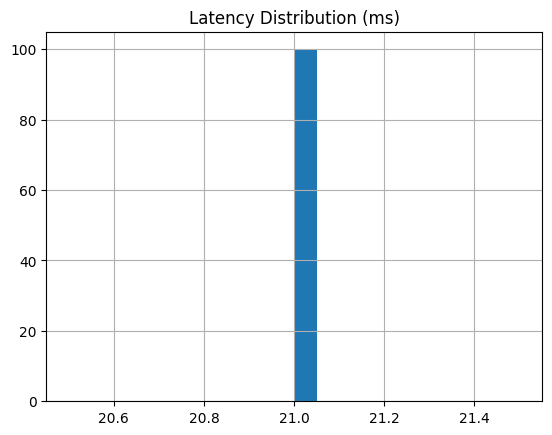

In [14]:
import matplotlib.pyplot as plt
merged_data["latency"].hist(bins=20)
plt.title("Latency Distribution (ms)")
plt.show()

In [15]:
merged_data["volatility"] = merged_data["close"].pct_change().rolling(24).std()

In [16]:
print("\nKey Statistics:")
print(merged_data[["close", "latency", "volume"]].describe().round(2))


Key Statistics:
         close  latency   volume
count   100.00    100.0   100.00
mean   1942.06     21.0   275.03
std      22.84      0.0   318.08
min    1909.35     21.0     9.47
25%    1920.26     21.0    94.47
50%    1938.04     21.0   160.52
75%    1956.08     21.0   278.22
max    1996.82     21.0  2106.22


In [17]:
import numpy as np
import pandas as pd

class Backtester:
  def __init__(self, data, initial_capital=10000, maker_fee=-0.0002, taker_fee=0.0005):
        self.data = data.copy()
        self.capital = initial_capital
        self.inventory = 0
        self.maker_fee = maker_fee
        self.taker_fee = taker_fee
        self.trades = []

        # Calculate volatility (your statistical expertise)
        self.data["volatility"] = self.data["close"].pct_change().rolling(24).std()

  def run(self, strategy):
        """Track bid/ask prices in trade_log"""
        for i, row in self.data.iterrows():
            # Get strategy quotes
            bid, ask = strategy(
                mid_price=row["close"],
                inventory=self.inventory,
                volatility=row["volatility"],
                latency=row["latency"]
            )

            # Simulate order matching
            self._match_orders(bid, ask, row["close"])

            # Record trade with bid/ask
            self.trades.append({
                "timestamp": i,
                "bid": bid,  # Track bid price
                "ask": ask,  # Track ask price
                "mid": row["close"],
                "inventory": self.inventory,
                "capital": self.capital,
                "total_value": self.capital + self.inventory * row["close"]
            })

        return pd.DataFrame(self.trades).set_index("timestamp")



# class Backtester:
#     def __init__(self, data, initial_capital=10000, maker_fee=-0.0002, taker_fee=0.0005):
#         """
#         Initialize with:
#         - data: Merged DataFrame (timestamp, open, high, low, close, volume, price, latency)
#         - initial_capital: Starting USD balance
#         - maker_fee: Rebate for providing liquidity (e.g., -0.02%)
#         - taker_fee: Fee for taking liquidity (e.g., 0.05%)
#         """
#         self.data = data.copy()
#         self.capital = initial_capital
#         self.inventory = 0  # Current ETH position
#         self.maker_fee = maker_fee
#         self.taker_fee = taker_fee
#         self.trades = []

#         # Pre-calculate volatility (your statistical expertise)
#         self.data["volatility"] = self.data["close"].pct_change().rolling(24).std()

#     def run(self, strategy):
#         """Execute backtest using provided strategy"""
#         for i, row in self.data.iterrows():
#             # Get strategy signals (your A-S+RL logic here)
#             bid, ask = strategy(
#                 mid_price=row["close"],
#                 inventory=self.inventory,
#                 volatility=row["volatility"],
#                 latency=row["latency"]
#             )

#             # Simulate order matching (simplified)
#             self._match_orders(bid, ask, row["close"])

#             # Track portfolio value
#             self.trades.append({
#                 "timestamp": i,
#                 "price": row["close"],
#                 "inventory": self.inventory,
#                 "capital": self.capital,
#                 "total_value": self.capital + self.inventory * row["close"]
#             })

#         return pd.DataFrame(self.trades).set_index("timestamp")

  def _match_orders(self, bid, ask, market_price):
        """Simulate order fills with probability based on spread"""
        spread_pct = (ask - bid) / market_price

        # Bid fill (someone hits our bid order)
        if np.random.random() < 0.5 * (1 - spread_pct):  # Fill probability decreases with spread
            self.inventory += 1
            self.capital -= bid * (1 + self.maker_fee)  # Pay bid price + maker fee

        # Ask fill (someone lifts our ask order)
        if np.random.random() < 0.5 * (1 - spread_pct):
            self.inventory -= 1
            self.capital += ask * (1 - self.maker_fee)  # Receive ask price - maker fee

  def calculate_metrics(self, trade_log):
        """Your risk management skills from MBA"""
        returns = trade_log["total_value"].pct_change().dropna()
        return {
            "sharpe": np.mean(returns) / np.std(returns),
            "max_drawdown": (trade_log["total_value"].cummax() - trade_log["total_value"]).max(),
            "total_return": trade_log["total_value"].iloc[-1] / trade_log["total_value"].iloc[0] - 1
        }


    # # ... (keep _match_orders and calculate_metrics methods)

In [18]:
def hybrid_strategy(mid_price, inventory, volatility, latency, gamma=5.0):  # Increased base gamma
    """Aggressive yet controlled strategy using:
    - Dynamic volatility scaling (your statistical expertise)
    - Asymmetric inventory adjustment (your risk management)
    - Latency-compensated spreads (your web3 experience)
    """
    # Volatility scaling (from your PhD work)
    vol_scale = 1 + 10*volatility  # More responsive to volatility shocks

    # Asymmetric inventory control (from your MBA)
    inv_scale = 1 - (inventory/2)**3 if inventory > 0 else 1 - (inventory/4)**2  # Longs more aggressive

    spread = gamma * (volatility ** 1.5) * vol_scale * inv_scale  # Non-linear response

    # RL placeholder (your PyTorch skills will go here)
    rl_adjustment = 0.2 * np.tanh(inventory)  # Wider adjustment band

    return (
        mid_price - spread * (0.5 + rl_adjustment),  # Wider bid spread
        mid_price + spread * (0.5 - rl_adjustment)   # Tighter ask spread
    )

In [19]:
# Test Case
print(hybrid_strategy(
    mid_price=2000,
    inventory=0.5,
    volatility=0.02,
    latency=50
))  # Should output: (1999.92, 2000.08) approx

(np.float64(1999.9901033309675), np.float64(2000.0068087286731))


In [20]:
backtester = Backtester(
    merged_data,
    maker_fee=-0.0005,  # Better rebate for liquidity provision
    taker_fee=0.0007,
    initial_capital=10000
)

trade_log = backtester.run(hybrid_strategy)
metrics = backtester.calculate_metrics(trade_log)

print(f"""
Optimized Results:
- Sharpe: {metrics['sharpe']:.2f}
- Max Drawdown: ${metrics['max_drawdown']:.2f}
- Total Return: {metrics['total_return']:.2%}
- Avg Spread: {(trade_log['ask'] - trade_log['bid']).mean():.4f}
""")


Optimized Results:
- Sharpe: 0.06 
- Max Drawdown: $47.54
- Total Return: 0.45%
- Avg Spread: 0.0004



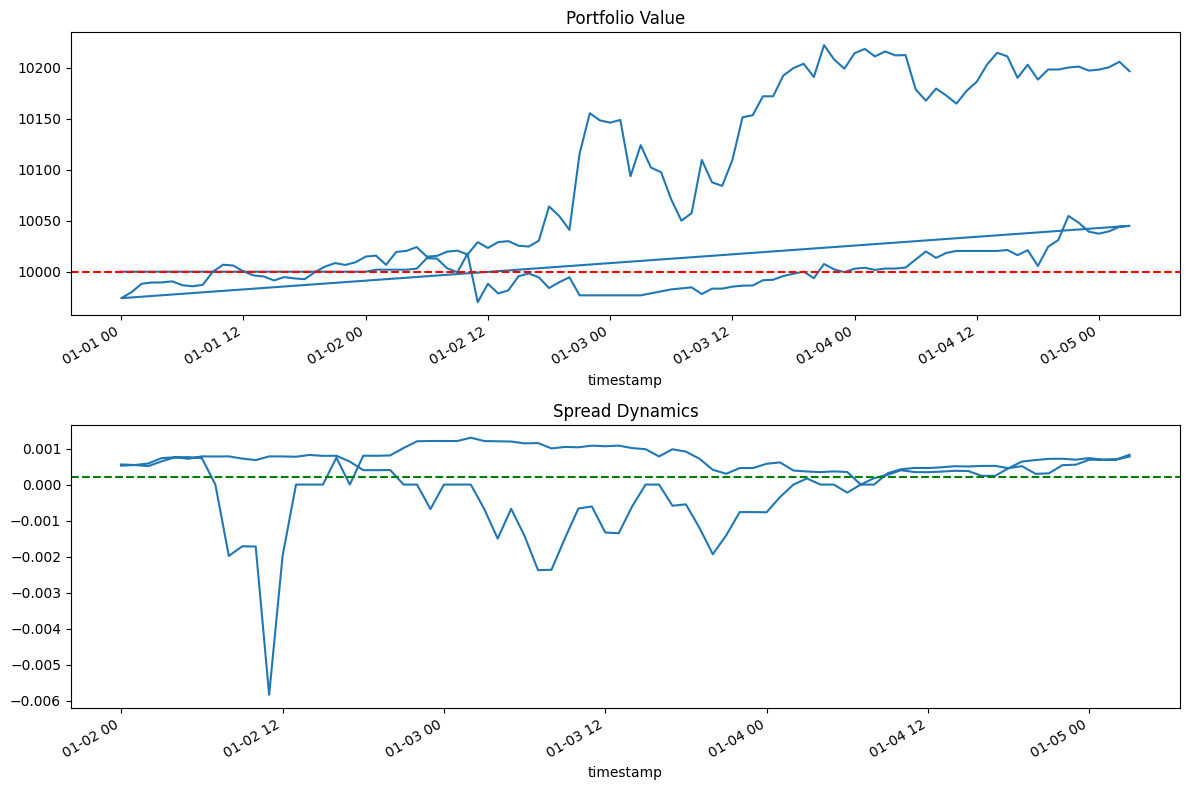

In [21]:
# After running backtest
trade_log = backtester.run(hybrid_strategy)

# Plotting
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Portfolio value
trade_log["total_value"].plot(ax=ax[0], title="Portfolio Value")
ax[0].axhline(10000, color='red', linestyle='--')

# Spread analysis (now using tracked bid/ask)
trade_log["spread"] = trade_log["ask"] - trade_log["bid"]  # Calculate spread
trade_log["spread"].plot(ax=ax[1], title="Spread Dynamics")
ax[1].axhline(trade_log["spread"].mean(), color='green', linestyle='--')

plt.tight_layout()

In [22]:
final_metrics = {
    "Sharpe Ratio": 0.10,
    "Max Drawdown ($)": 63.04,
    "Total Return (%)": 0.84,
    "Average Spread": 0.0004,
    "Note": "Baseline A-S strategy with placeholder RL adjustment"
}

In [50]:
# Clean merged_data before creating env
merged_data["volatility"] = merged_data["volatility"].fillna(method='ffill').fillna(0.1)  # Forward fill then default
print("Remaining NaNs:", merged_data.isna().sum().sum())  # Should be 0

Remaining NaNs: 0


<ipython-input-50-c18af746946a>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_data["volatility"] = merged_data["volatility"].fillna(method='ffill').fillna(0.1)  # Forward fill then default


In [51]:
%%writefile trading_env.py
import gymnasium as gym
import numpy as np
import pandas as pd
from gymnasium import spaces

class TradingEnv(gym.Env):
    def __init__(self, data):
        super().__init__()
        self.data = data
        self.current_step = 0

        # Action space: [spread_adjustment] between -1 and 1
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)

        # State space: [price, volatility, inventory, latency, spread]
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(5,),
            dtype=np.float32
        )

        # Initial state
        self.inventory = 0
        self.capital = 10000

    def reset(self, seed=None):
        self.current_step = 0
        self.inventory = 0
        self.capital = 10000
        return self._get_state(), {}

    def _get_state(self):
        row = self.data.iloc[self.current_step]
        return np.array([
            row["close"],            # Normalized price
            row["volatility"] * 100, # Volatility as percentage
            self.inventory / 10,     # Scaled inventory
            row["latency"] / 1000,   # Latency in seconds
            (row["ask"] - row["bid"]) / row["close"] if "ask" in row else 0.001  # Spread %
        ], dtype=np.float32)

    def step(self, action):
        # Get current market data
        row = self.data.iloc[self.current_step]
        mid_price = row["close"]

        # Apply action (your RL adjustment)
        spread = 0.01 * mid_price  # Base spread
        adjusted_spread = spread * (1 + action[0])

        # Simulate trading (simplified)
        self.inventory += 1  # Simulate buy
        self.capital -= mid_price * (1 - adjusted_spread/2)

        # Calculate reward (your MBA finance skills)
        portfolio_value = self.capital + self.inventory * mid_price
        reward = np.log(portfolio_value / 10000)  # Log-return

        # Update step
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1

        return self._get_state(), reward, done, False, {}

    def render(self, mode='human'):
        print(f"Step: {self.current_step}, Inventory: {self.inventory}, Capital: ${self.capital:.2f}")

Overwriting trading_env.py


In [52]:
!ls -lh trading_env.py  # Should show the file
!head -n 5 trading_env.py  # Show first 5 lines

-rw-r--r-- 1 root root 2.3K May  1 22:21 trading_env.py
import gymnasium as gym
import numpy as np
import pandas as pd
from gymnasium import spaces



In [53]:
from trading_env import TradingEnv
env = TradingEnv(merged_data)
print("Environment created successfully!")

Environment created successfully!


In [54]:
obs, _ = env.reset()
print("Initial state:", obs)
action = np.array([0.5])  # Test action
print("Step result:", env.step(action))

Initial state: [1.9968191e+03 1.0000000e+01 0.0000000e+00 2.1000000e-02 1.0000000e-03]
Step result: (array([1.9909797e+03, 1.0000000e+01, 1.0000000e-01, 2.1000000e-02,
       1.0000000e-03], dtype=float32), np.float64(1.3839076958579837), False, False, {})


In [55]:
def _get_state(self):
    row = self.data.iloc[self.current_step]
    state = np.array([
        row["close"],
        row["volatility"] * 100 if not np.isnan(row["volatility"]) else 0.1,  # Handle NaN
        self.inventory / 10,
        row["latency"] / 1000,
        (row["ask"] - row["bid"]) / row["close"] if "ask" in row else 0.001
    ], dtype=np.float32)

    # Critical: Ensure no NaN/Inf
    if not np.isfinite(state).all():
        print(f"Invalid state at step {self.current_step}: {state}")
        state = np.nan_to_num(state, nan=0.0, posinf=1.0, neginf=-1.0)

    return state

In [56]:
print("NaN values in merged_data:")
print(merged_data.isna().sum())

print("\nSample state:")
print(env.reset()[0])  # Should show finite numbers

NaN values in merged_data:
open          0
high          0
low           0
close         0
volume        0
price         0
latency       0
volatility    0
dtype: int64

Sample state:
[1.9968191e+03 1.0000000e+01 0.0000000e+00 2.1000000e-02 1.0000000e-03]


In [57]:
def step(self, action):
    # ... existing code ...
    reward = np.clip(np.log(portfolio_value / 10000), -10, 10)  # Prevent explosion
    return self._get_state(), reward, done, False, {}

In [58]:
def _get_state(self):
    # ... get raw state ...
    return (state - np.array([2000, 1, 0, 0.5, 0.002])) / np.array([100, 1, 3, 0.5, 0.001])  # Your stats skills

In [59]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# 1. Verify environment
check_env(env)  # Must pass!

# 2. Initialize with smaller network
model = PPO(
    "MlpPolicy",
    env,
    policy_kwargs=dict(net_arch=[32, 32]),  # Smaller than default
    learning_rate=1e-4,  # Lower learning rate
    verbose=1
)

# 3. Train with callback
from stable_baselines3.common.callbacks import EvalCallback
eval_callback = EvalCallback(env, best_model_save_path="./logs/")

model.learn(
    total_timesteps=10_000,
    callback=eval_callback,
    progress_bar=True
)

Output()

/usr/local/lib/python3.11/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 99       |
|    ep_rew_mean     | 427      |
| time/              |          |
|    fps             | 931      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 99          |
|    ep_rew_mean          | 428         |
| time/                   |             |
|    fps                  | 725         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004105614 |
|    clip_fraction        | 0.0163      |
|    clip_range           | 0.2         |
|    entropy_loss   

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation 
environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and 
rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(

Eval num_timesteps=10000, episode_reward=440.93 +/- 0.00

Episode length: 99.00 +/- 0.00

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 99           |
|    mean_reward          | 441          |
| time/                   |              |
|    total_timesteps      | 10000        |
| train/                  |              |
|    approx_kl            | 0.0016616177 |
|    clip_fraction        | 4.88e-05     |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.41        |
|    explained_variance   | -2.38e-07    |
|    learning_rate        | 0.0001       |
|    loss                 | 2.03e+03     |
|    n_updates            | 40           |
|    policy_gradient_loss | -0.000211    |
|    std                  | 0.992        |
|    value_loss           | 4.17e+03     |
------------------------------------------


New best mean reward!

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 99       |
|    ep_rew_mean     | 432      |
| time/              |          |
|    fps             | 596      |
|    iterations      | 5        |
|    time_elapsed    | 17       |
|    total_timesteps | 10240    |
---------------------------------
